### 08 - Cross-Validation: SVR Kernel Comparison

TimeSeriesSplit (5 folds) comparing linear, RBF and polynomial kernels on the training set (2022-2024).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/08_cv', exist_ok=True)

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

FEATURES = ['T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend']

df = df.dropna(subset=FEATURES)

#### 1. Data Preparation

In [2]:
train = df[df.index.year < 2025]

scaler  = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES].values)
y_train = train['demand_log'].values

# subsample 10K preserving temporal order — SVR is O(n^2)
rng = np.random.default_rng(42)
idx = np.sort(rng.choice(len(X_train), size=10_000, replace=False))
X_cv, y_cv = X_train[idx], y_train[idx]

print(f'Full train: {len(X_train):,}  |  CV subsample: {len(X_cv):,}')

Full train: 26,260  |  CV subsample: 10,000


#### 2. Cross-Validation

TimeSeriesSplit keeps each validation fold in the future relative to training.
Random KFold would leak future data into the past, which is wrong for time series.

In [3]:
tscv = TimeSeriesSplit(n_splits=5)

variants = {
    'linear': SVR(kernel='linear'),
    'RBF':    SVR(kernel='rbf', C=100, gamma=0.01),
    'poly3':  SVR(kernel='poly', degree=3),
}

cv_results = {name: {'rmse': [], 'mae': []} for name in variants}

for name, svr in variants.items():
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_cv)):
        svr.fit(X_cv[tr_idx], y_cv[tr_idx])
        y_pred = np.exp(svr.predict(X_cv[val_idx]))
        y_true = np.exp(y_cv[val_idx])

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        cv_results[name]['rmse'].append(rmse)
        cv_results[name]['mae'].append(mae)

    print(f'{name:8s}  RMSE {np.mean(cv_results[name]["rmse"]):,.0f} +/- {np.std(cv_results[name]["rmse"]):,.0f}'
          f'   MAE {np.mean(cv_results[name]["mae"]):,.0f} +/- {np.std(cv_results[name]["mae"]):,.0f}')

linear    RMSE 7,994 +/- 467   MAE 6,402 +/- 346


RBF       RMSE 5,392 +/- 235   MAE 3,936 +/- 278


poly3     RMSE 7,265 +/- 1,528   MAE 5,611 +/- 1,397


#### 3. Results Table

In [4]:
rows = []
for name, res in cv_results.items():
    rows.append({
        'kernel':    name,
        'RMSE mean': round(np.mean(res['rmse'])),
        'RMSE std':  round(np.std(res['rmse'])),
        'MAE mean':  round(np.mean(res['mae'])),
        'MAE std':   round(np.std(res['mae'])),
    })

summary = pd.DataFrame(rows).set_index('kernel')
summary

,RMSE mean,RMSE std,MAE mean,MAE std
kernel,,,,
linear,7994,467,6402,346
RBF,5392,235,3936,278
poly3,7265,1528,5611,1397


#### 4. Boxplot by Fold

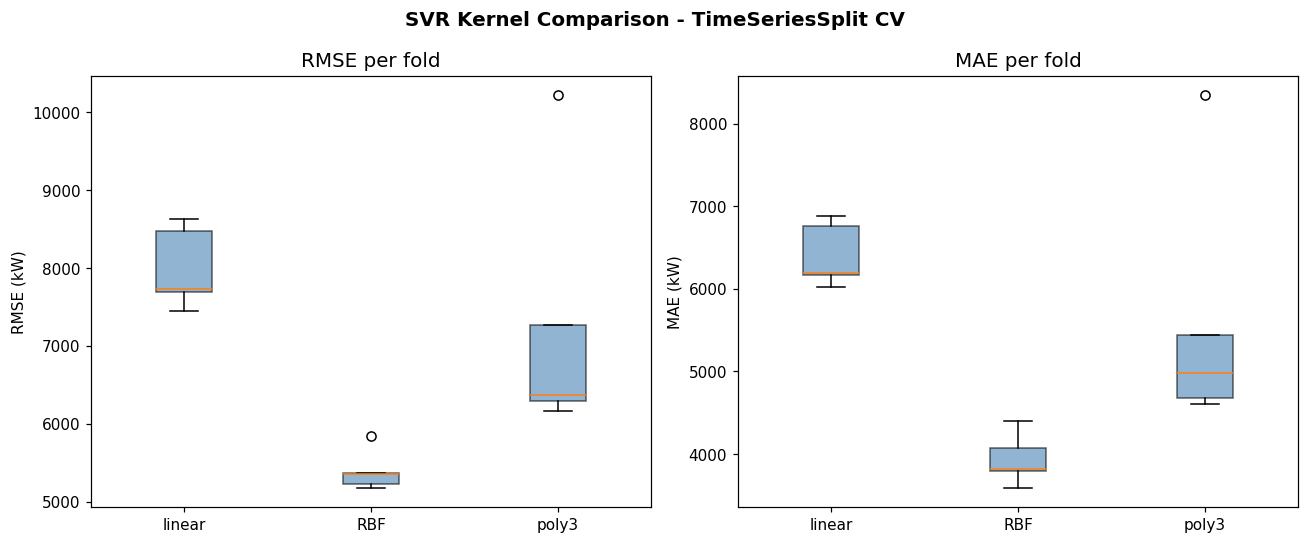

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = list(cv_results.keys())

axes[0].boxplot([cv_results[n]['rmse'] for n in labels], tick_labels=labels, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_ylabel('RMSE (kW)')
axes[0].set_title('RMSE per fold')

axes[1].boxplot([cv_results[n]['mae'] for n in labels], tick_labels=labels, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('MAE (kW)')
axes[1].set_title('MAE per fold')

fig.suptitle('SVR Kernel Comparison - TimeSeriesSplit CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/08_cv/08_19_cv_boxplot.png', bbox_inches='tight')
plt.show()

#### 5. Conclusion

RBF wins on all folds, consistent with notebook 06. Poly3 is the least stable (std ~1500),
probably overfitting on smaller folds. Linear is reasonable but misses non-linear patterns.

TimeSeriesSplit is the right call: each fold trains on the past and tests on the future.
Random KFold would let the model train on 2024 to predict 2022, which makes no sense.